# Preparing algoirthm to crop images to objects

In [56]:
from ultralytics import YOLO
from random import randint
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

VEHICLE_CLASSES = [
    1,   # bicycle
    2,   # car
    3,   # motocycle
    5,   # bus
    7    # truck 
]
PERSON_CLASSES = [0]
TARGET_CLASSES = VEHICLE_CLASSES + PERSON_CLASSES

### Initialize model

In [57]:
model = YOLO('yolov8n.pt')

### Load data

In [58]:
path = Path(r"..\datasets\DoTA\frames\train\0qfbmt4G8Rw_001060\images")

image_paths = list(path.glob('*.jpg'))
print(f" # of images: {len(image_paths)}")

 # of images: 140


### Show random frames

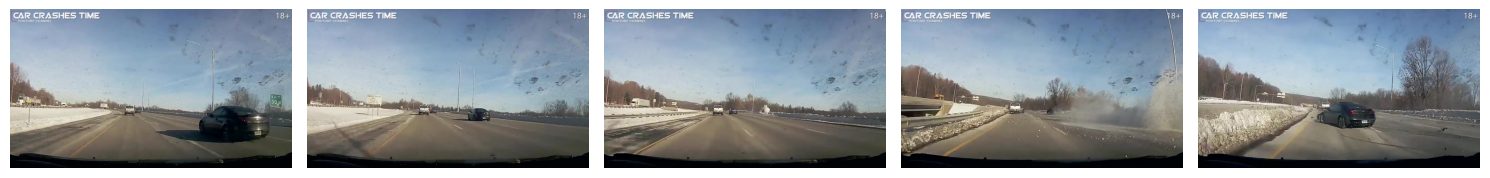

In [59]:
n = 5
indices = [randint(0, len(image_paths)) for _ in range(n)]
indices.sort()

fig, axs = plt.subplots(1, n, figsize=(15, 15))

for i, idx in enumerate(indices):
    axs[i].imshow(cv2.imread(str(image_paths[idx]), cv2.IMREAD_COLOR_RGB))
    axs[i].axis('off')

plt.tight_layout()

### Detection with YOLO


0: 384x640 1 car, 1 truck, 25.8ms
Speed: 3.4ms preprocess, 25.8ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 24.8ms
Speed: 3.3ms preprocess, 24.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 24.5ms
Speed: 3.0ms preprocess, 24.5ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 1 boat, 24.2ms
Speed: 3.2ms preprocess, 24.2ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 airplane, 2 trucks, 22.3ms
Speed: 2.7ms preprocess, 22.3ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


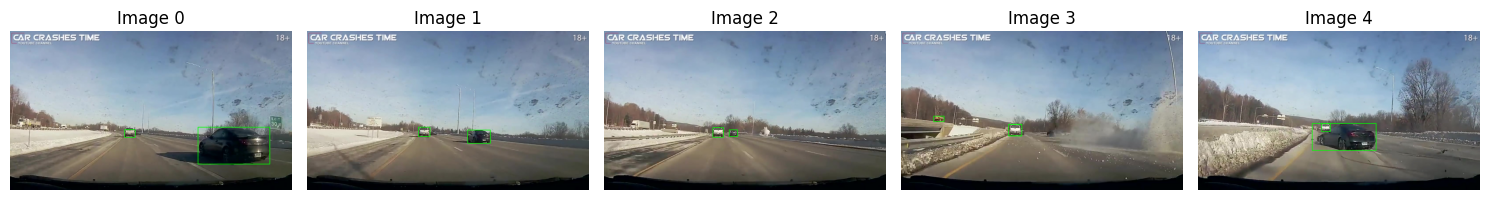

In [60]:
fig, axes = plt.subplots(1, len(indices), figsize=(15, 5))

for i, idx in enumerate(indices):
    img = cv2.imread(str(image_paths[idx]), cv2.IMREAD_COLOR_RGB)
    result = model.predict(img)[0]
    for box in result.boxes:
        if box.cls in TARGET_CLASSES:
            x1, y1, x2, y2 = map(int, box.xyxy.tolist()[0])
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i}")

plt.tight_layout()
plt.show()
        

### Cropping top of the images

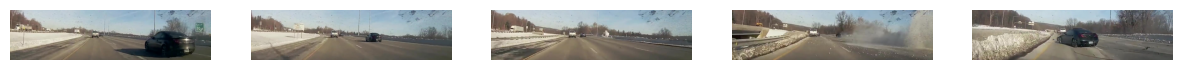

In [71]:
fig, axes = plt.subplots(1, len(indices), figsize=(15, 5))

for i, idx in enumerate(indices):
    axes[i].imshow(cv2.imread(str(image_paths[idx]), cv2.IMREAD_COLOR_RGB)[300:-100])
    axes[i].axis('off')

In [62]:
indices

[9, 24, 60, 81, 107]